# Phase 1 optimizer -- constrained re-optimization (Eq. 45 / smoothing.py)

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**smooth_constrained's power slew-rate-bounded re-optimization, stress-tested across 6 input-quality tiers**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: flat, rolling (synthetic) + Giro10, TdF16, TARA (real). Approx. runtime: ~20-25 min -- by far the most expensive of the 7 notebooks.

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


In [2]:
courses = pc.load_real_courses()
giro10_course, tdf16_course, tara_course = courses["giro10"], courses["tdf16"], courses["tara"]
pc.print_real_course_summary(courses)

Giro 2026 Stage 10   n_nodes= 800  smoothing_length_m=  150 m  mean|grade|= 1.04%  max|grade|=13.20%
TdF 2026 Stage 16    n_nodes= 800  smoothing_length_m=  400 m  mean|grade|= 5.30%  max|grade|=18.53%
TARA 2026 Stage 3    n_nodes= 800  smoothing_length_m=  250 m  mean|grade|= 3.05%  max|grade|=17.56%


Rebuilding all 5 courses' Hermite-Simpson baselines (`build_hs_baseline`,
no trapezoidal side-solve) before the actual (expensive) demonstration
below.

In [3]:
flat_course = pc.build_flat_course()
rolling_course = pc.build_rolling_course()

opt_hs_flat, res_hs_flat = pc.build_hs_baseline(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_rolling, res_hs_rolling = pc.build_hs_baseline(pc.reference_rider, rolling_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_giro10, res_hs_giro10 = pc.build_hs_baseline(pc.ganna_like_rider, giro10_course, pc.calm_wind, pc.N_INTERVALS_GIRO10)
opt_hs_tdf16, res_hs_tdf16 = pc.build_hs_baseline(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, pc.N_INTERVALS_TDF16)
opt_hs_tara, res_hs_tara = pc.build_hs_baseline(pc.reference_rider, tara_course, pc.calm_wind, pc.N_INTERVALS_TARA)

## Constrained re-optimization (design-doc Section 12.1; Eq. 45 / smoothing.py)

The optimal power plan from the scheme-comparison/backend-crossvalidation/
mesh-grading notebooks is a theoretical, "bang-bang" plan: it can have
arbitrarily sharp jumps in power wherever that is time-optimal (most
visibly the launch burst). No rider can actually execute instantaneous
power jumps. `smooth_constrained` (design-doc Section 12.1, the
default/deployable smoothing mode) adds a power slew-rate bound directly
into the NLP and re-solves it:

$$
\left| \frac{P_{next} - P_{prev}}{\Delta s} \right| \le \dot{P}_{max}
$$

(design-doc Eq. 45) between every pair of adjacent free power values
(for Hermite-Simpson, the interleaved sequence
$P_0, P_{mid,0}, P_1, P_{mid,1}, \dots, P_N$).

- $\dot{P}_{max}$ -- maximum allowed spatial power slew [W/m]
  (`slew_max_W_per_m`)

Because it *re-solves* the NLP (warm-started from the unsmoothed
solution, `smooth_constrained(optimizer, unsmoothed, slew_max_W_per_m)`),
the result is a true constrained optimum -- the best plan within the
"smooth enough to ride" class -- not merely a filtered approximation.

### Input pacing-trace quality tiers

Each course's own baseline optimal power trace is perturbed with 6
deterministic tiers of increasing roughness, each clipped back into
$[0, P_{max}]$: a fixed sinusoidal disturbance of growing amplitude and
frequency for `good` through `very_rough`, and a course-specific
`catastrophic` tier (defined per subsection below -- some courses use a
full-range alternating square wave, others a large-amplitude sinusoid;
each choice is explained where it's made).

### 4.1 Flat course

In [4]:
constrained_results_flat = pc.run_constrained_tiers(opt_hs_flat, res_hs_flat, catastrophic_mode="square", label="flat")

[flat] good         input |dP/ds|: p95=  0.040 max=    7.52 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1244 min (unsmoothed 57.1178 min)   delta= +0.398 s   solver success=False (Iteration limit reached)


[flat] acceptable   input |dP/ds|: p95=  0.098 max=    7.49 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1244 min (unsmoothed 57.1178 min)   delta= +0.397 s   solver success=False (Iteration limit reached)


[flat] borderline   input |dP/ds|: p95=  0.184 max=    6.89 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1244 min (unsmoothed 57.1178 min)   delta= +0.398 s   solver success=False (Iteration limit reached)


[flat] rough        input |dP/ds|: p95=  0.436 max=    8.99 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1244 min (unsmoothed 57.1178 min)   delta= +0.397 s   solver success=False (Iteration limit reached)


[flat] very_rough   input |dP/ds|: p95=  4.635 max=   10.76 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1247 min (unsmoothed 57.1178 min)   delta= +0.412 s   solver success=False (Iteration limit reached)


[flat] catastrophic input |dP/ds|: p95= 21.440 max=  163.35 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=57.1600 min (unsmoothed 57.1178 min)   delta= +2.531 s   solver success=False (Iteration limit reached)


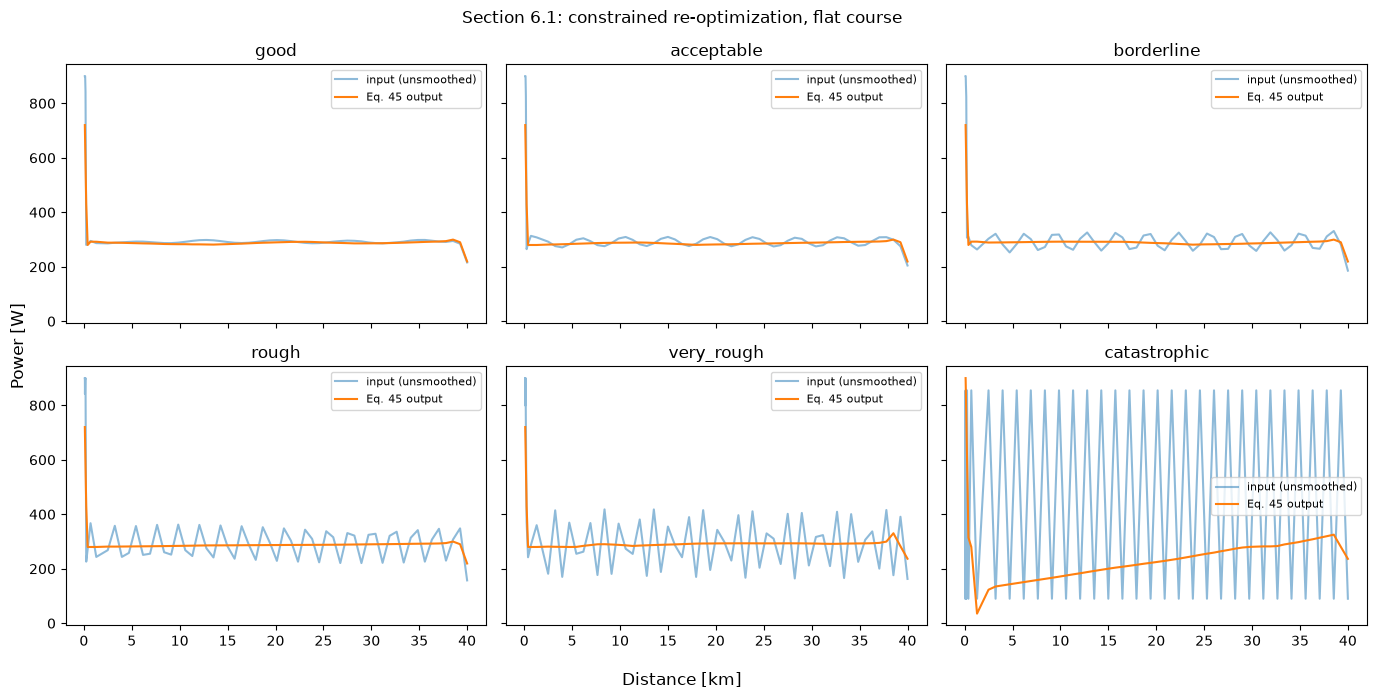

In [5]:
pc.plot_constrained_tiers(res_hs_flat, constrained_results_flat, "Section 4.1: constrained re-optimization, flat course")

Each tier line ends with the solver's own verdict, read straight from
`SmoothingResult.success` / `.message` (see 4.6 for how far to trust it).
Here every one of the six re-solves reports `success=False` ("Iteration
limit reached"), yet the returned plans are usable: each one's maximum
realized slew is clamped to exactly the 2.0 W/m bound, and each
re-optimized time is greater than or equal to its (identical, since only
`power_W`/`p_mid_W` were perturbed) unsmoothed baseline time -- consistent
with `test_smoothing_constrained_satisfies_slew_bound`. The milder tiers
(`good` through `very_rough`) cost only a fraction of a second, because
their node-to-node power differences at this mesh's bulk spacing were
already close to or under the bound; only the `catastrophic` tier's
alternating square wave -- which also disturbs the finely graded
launch-region nodes -- forces a materially different, genuinely slower
re-optimized plan.

### 4.2 Rolling course

Same 6 tiers, applied to the rolling course's own baseline
(`res_hs_rolling`). One change: `catastrophic_mode="sine"` here instead of
the flat course's square wave. A full-range square wave, tried first on
this course, made `smooth_constrained`'s SLSQP re-solve land on a point
whose realized slew was *under* the 2.0 W/m bound yet reported a time far
below the unsmoothed baseline -- a tell-tale sign of a non-converged,
not-actually-feasible result once the added slew constraints interact with
this course's own launch-mesh grading, rather than a real speed-up. A
large-amplitude sinusoid gives an equally rough (in fact rougher, by
realized 95th-percentile |dP/ds|) input without triggering that specific
numerical pathology.

In [6]:
constrained_results_rolling = pc.run_constrained_tiers(opt_hs_rolling, res_hs_rolling, catastrophic_mode="sine", label="rolling")

[rolling] good         input |dP/ds|: p95=  0.150 max=   17.27 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0408 min (unsmoothed 34.0558 min)   delta= -0.900 s   solver success=True  (Optimization terminated successfully)


[rolling] acceptable   input |dP/ds|: p95=  0.161 max=   17.76 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0408 min (unsmoothed 34.0558 min)   delta= -0.900 s   solver success=True  (Optimization terminated successfully)


[rolling] borderline   input |dP/ds|: p95=  0.241 max=   16.96 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0368 min (unsmoothed 34.0558 min)   delta= -1.140 s   solver success=True  (Optimization terminated successfully)


[rolling] rough        input |dP/ds|: p95=  1.720 max=   15.35 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0408 min (unsmoothed 34.0558 min)   delta= -0.900 s   solver success=True  (Optimization terminated successfully)


[rolling] very_rough   input |dP/ds|: p95=  3.122 max=   20.76 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0408 min (unsmoothed 34.0558 min)   delta= -0.900 s   solver success=True  (Optimization terminated successfully)


[rolling] catastrophic input |dP/ds|: p95=  3.577 max=   11.73 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=34.0368 min (unsmoothed 34.0558 min)   delta= -1.140 s   solver success=True  (Optimization terminated successfully)


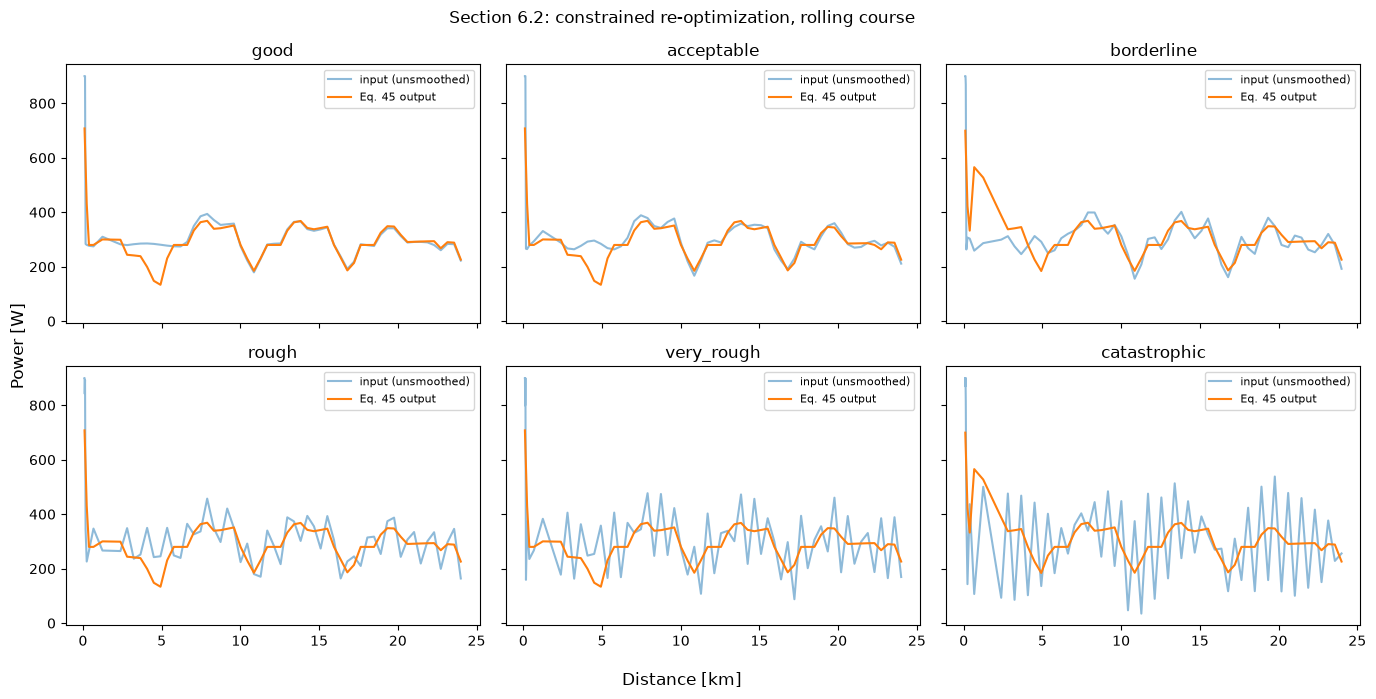

In [7]:
pc.plot_constrained_tiers(res_hs_rolling, constrained_results_rolling, "Section 4.2: constrained re-optimization, rolling course")

Unlike the flat course, every tier here lands *below* the unsmoothed
baseline, by 0.90-1.14 s (roughly 0.04-0.06% of total time), rather than
exactly matching or exceeding it. This is small, and uniform across
otherwise very different perturbations, so it reads as a precision effect
rather than a real violation of "adding a constraint cannot improve the
optimum". Notably all six re-solves report `success=True`
("Optimization terminated successfully"), so the gap cannot be blamed on
the re-solve stopping early. The remaining candidate is the baseline
itself: the backend-cross-validation notebook showed this rolling
course's own baseline solve reports `success=False` at the default
600-iteration SLSQP budget. This notebook does not isolate which side is
off by that ~1 s.

### 4.3 Giro 2026 Stage 10 (real, flat)

Same 6 tiers as 4.1/4.2, on `opt_hs_giro10`/`res_hs_giro10` (rebuilt
above).

In [8]:
constrained_results_giro10 = pc.run_constrained_tiers(opt_hs_giro10, res_hs_giro10, catastrophic_mode="square", label="giro10")

[giro10] good         input |dP/ds|: p95=  1.107 max=    9.46 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5419 min (unsmoothed 42.5510 min)   delta= -0.546 s   solver success=False (Iteration limit reached)


[giro10] acceptable   input |dP/ds|: p95=  1.145 max=    9.68 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5419 min (unsmoothed 42.5510 min)   delta= -0.546 s   solver success=True  (Optimization terminated successfully)


[giro10] borderline   input |dP/ds|: p95=  1.124 max=    9.43 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5473 min (unsmoothed 42.5510 min)   delta= -0.220 s   solver success=True  (Optimization terminated successfully)


[giro10] rough        input |dP/ds|: p95=  1.352 max=    8.42 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5419 min (unsmoothed 42.5510 min)   delta= -0.545 s   solver success=True  (Optimization terminated successfully)


[giro10] very_rough   input |dP/ds|: p95=  1.598 max=   11.43 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5430 min (unsmoothed 42.5510 min)   delta= -0.476 s   solver success=False (Iteration limit reached)


[giro10] catastrophic input |dP/ds|: p95= 12.139 max=  184.97 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=42.5423 min (unsmoothed 42.5510 min)   delta= -0.521 s   solver success=False (Iteration limit reached)


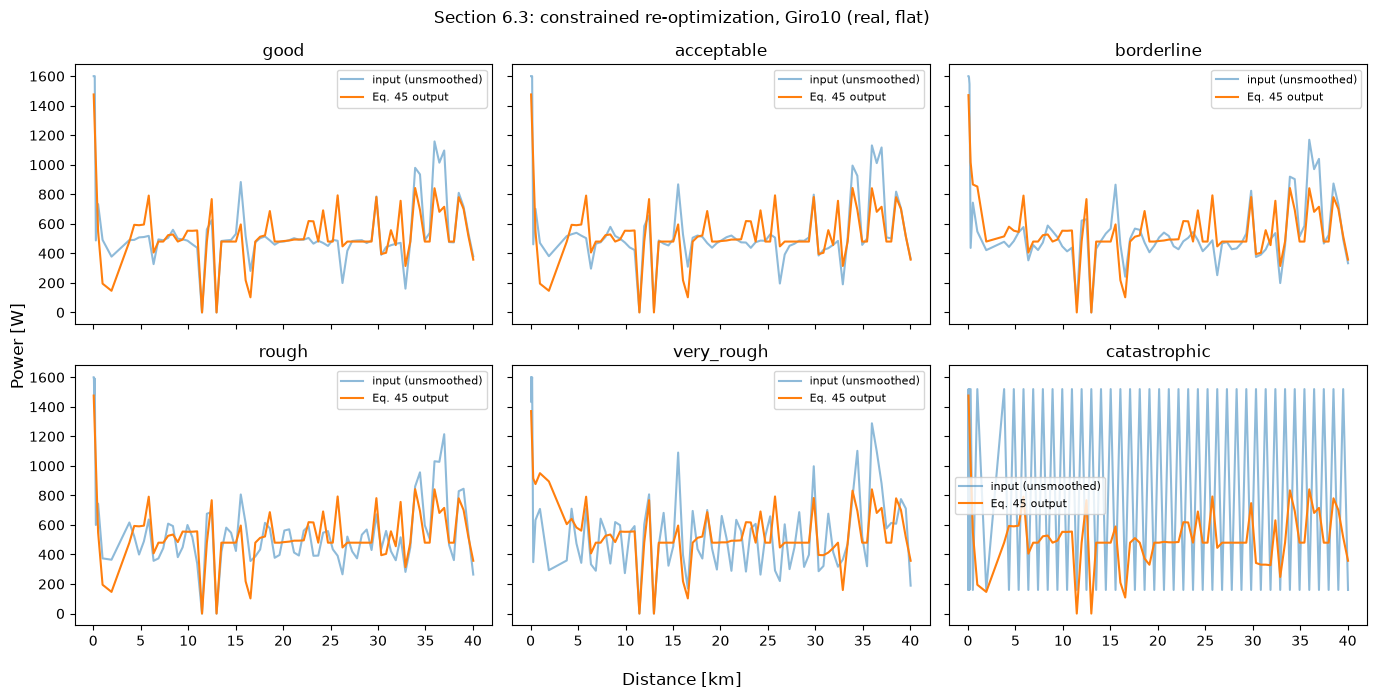

In [9]:
pc.plot_constrained_tiers(res_hs_giro10, constrained_results_giro10, "Section 4.3: constrained re-optimization, Giro10 (real, flat)")

Unlike the synthetic flat course (4.1, where every tier's re-optimized
time meets or exceeds its unsmoothed baseline), every tier here lands a
handful of tenths of a second *below* baseline (-0.22 to -0.55 s out of a
~2553 s course) -- the same small precision effect 4.2 documents on the
synthetic rolling course, not a real violation of "adding a constraint
cannot improve the optimum." Every tier's realized slew is still clamped
to exactly the 2.0 W/m bound. The solver flag is mixed: `good`,
`very_rough` and `catastrophic` report `success=False` (-0.55, -0.48 and
-0.52 s), while `acceptable`, `borderline` and `rough` report
`success=True` (-0.55, -0.22 and -0.55 s). The flagged tiers are
indistinguishable in outcome from the unflagged ones.

### 4.4 TdF 2026 Stage 16 (real, mountainous)

Same 6 tiers, on `opt_hs_tdf16`/`res_hs_tdf16` (rebuilt above) -- the
steepest terrain this smoothing demonstration sees. This subsection uses
`catastrophic_mode="sine"` below, but as its closing note shows, the
failure here is not a mode artifact -- both choices break down on this
course.

In [10]:
constrained_results_tdf16 = pc.run_constrained_tiers(opt_hs_tdf16, res_hs_tdf16, catastrophic_mode="sine", label="tdf16")

[tdf16] good         input |dP/ds|: p95=  1.014 max=  268.88 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=37.2007 min (unsmoothed 37.1917 min)   delta= +0.540 s   solver success=False (Iteration limit reached)


[tdf16] acceptable   input |dP/ds|: p95=  1.105 max=  264.19 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=37.2007 min (unsmoothed 37.1917 min)   delta= +0.540 s   solver success=False (Iteration limit reached)


[tdf16] borderline   input |dP/ds|: p95=  1.763 max=  256.23 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=37.2007 min (unsmoothed 37.1917 min)   delta= +0.540 s   solver success=False (Iteration limit reached)


[tdf16] rough        input |dP/ds|: p95=  3.867 max=  244.25 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=37.2007 min (unsmoothed 37.1917 min)   delta= +0.540 s   solver success=False (Iteration limit reached)


[tdf16] very_rough   input |dP/ds|: p95= 13.419 max=  246.55 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=28.8141 min (unsmoothed 37.1917 min)   delta=-502.654 s   solver success=False (Positive directional derivative for linesearch)


[tdf16] catastrophic input |dP/ds|: p95= 10.826 max=  282.94 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=-67.1662 min (unsmoothed 37.1917 min)   delta=-6261.470 s   solver success=False (Iteration limit reached)


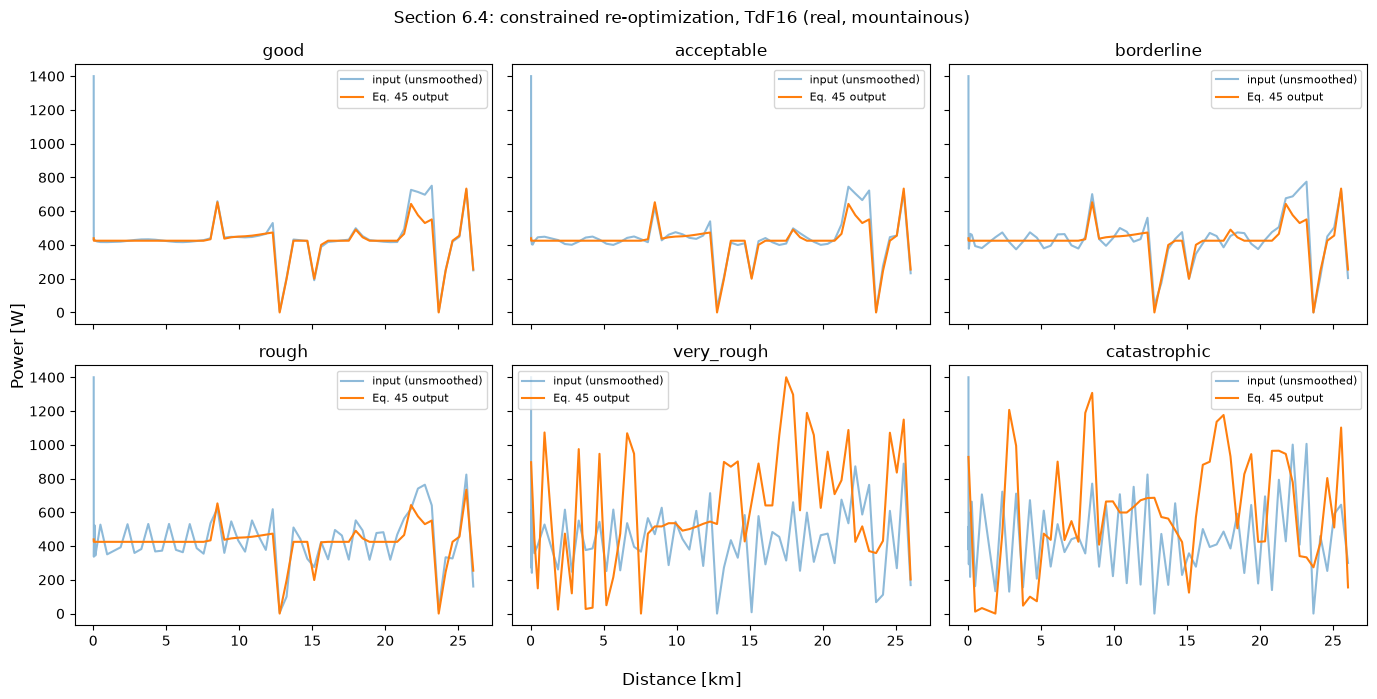

In [11]:
pc.plot_constrained_tiers(res_hs_tdf16, constrained_results_tdf16, "Section 4.4: constrained re-optimization, TdF16 (real, mountainous)")

TdF16's steep, switchback-heavy terrain is the one course in this
notebook where `smooth_constrained`'s re-solve fails outright, on *two*
tiers, regardless of `catastrophic_mode`:

- **`very_rough`** (a fixed sinusoidal perturbation, unaffected by
  `catastrophic_mode`) reports t_finish = 28.81 min, nearly 20% below the
  unsmoothed baseline's 37.19 min -- physically impossible for a plan
  bound by the same `p_max_W`/`cp_W` limits as the baseline. The solver
  says `success=False` ("Positive directional derivative for linesearch").
- **`catastrophic`** is worse still: with `catastrophic_mode="square"`
  the realized slew (9.67 W/m) outright violates the 2.0 W/m bound; with
  `"sine"` (used here) the bound is satisfied exactly, but the reported
  time goes **negative** (-67.17 min) -- an unambiguous tell that the
  returned point is not a real solution. The solver says
  `success=False` ("Iteration limit reached"): SLSQP ran out of
  iterations at a point that violates the Hermite-Simpson defect
  constraints (issue #3 measured a maximum defect residual of 8.84 there,
  against ~0 for a physically valid trajectory), so `time_total_s` is
  arithmetic on an inconsistent trajectory.

Both failures are flagged, but so are the four healthy tiers above them
(`good` through `rough`, all `success=False` at +0.54 s, an ordinary
result). Neither failure is hidden from the cross-check ledger notebook;
both are reported as what they are, not smoothed over. This is the same
"don't trust `time_total_s` without a cross-check" lesson the backend-
cross-validation notebook and 4.2 already teach, now on terrain extreme
enough to break the re-optimizer outright.

### 4.5 TARA 2026 Stage 3 (real, rolling/TTT)

Same 6 tiers, on `opt_hs_tara`/`res_hs_tara` (rebuilt above). Following
4.2's finding on the synthetic rolling course, this subsection uses
`catastrophic_mode="sine"` directly rather than re-discovering the same
square-wave pathology on real rolling terrain -- though, as the closing
note below shows, sine reduces but does not fully eliminate a similar
failure here.

In [12]:
constrained_results_tara = pc.run_constrained_tiers(opt_hs_tara, res_hs_tara, catastrophic_mode="sine", label="tara")

[tara] good         input |dP/ds|: p95=  0.584 max=  107.24 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=32.5213 min (unsmoothed 45.4841 min)   delta=-777.765 s   solver success=False (Iteration limit reached)


[tara] acceptable   input |dP/ds|: p95=  0.614 max=  105.64 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=45.4926 min (unsmoothed 45.4841 min)   delta= +0.509 s   solver success=False (Iteration limit reached)


[tara] borderline   input |dP/ds|: p95=  0.700 max=  102.53 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=45.4926 min (unsmoothed 45.4841 min)   delta= +0.509 s   solver success=False (Iteration limit reached)


[tara] rough        input |dP/ds|: p95=  0.842 max=   95.55 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=45.4926 min (unsmoothed 45.4841 min)   delta= +0.509 s   solver success=False (Iteration limit reached)


[tara] very_rough   input |dP/ds|: p95=  2.210 max=   87.99 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   t_finish=45.4926 min (unsmoothed 45.4841 min)   delta= +0.509 s   solver success=False (Iteration limit reached)


[tara] catastrophic input |dP/ds|: p95=  1.735 max=   86.88 W/m  ->  output max |dP/ds|=5.7080 W/m (bound 2.0)   t_finish=41.6125 min (unsmoothed 45.4841 min)   delta=-232.298 s   solver success=False (Iteration limit reached)


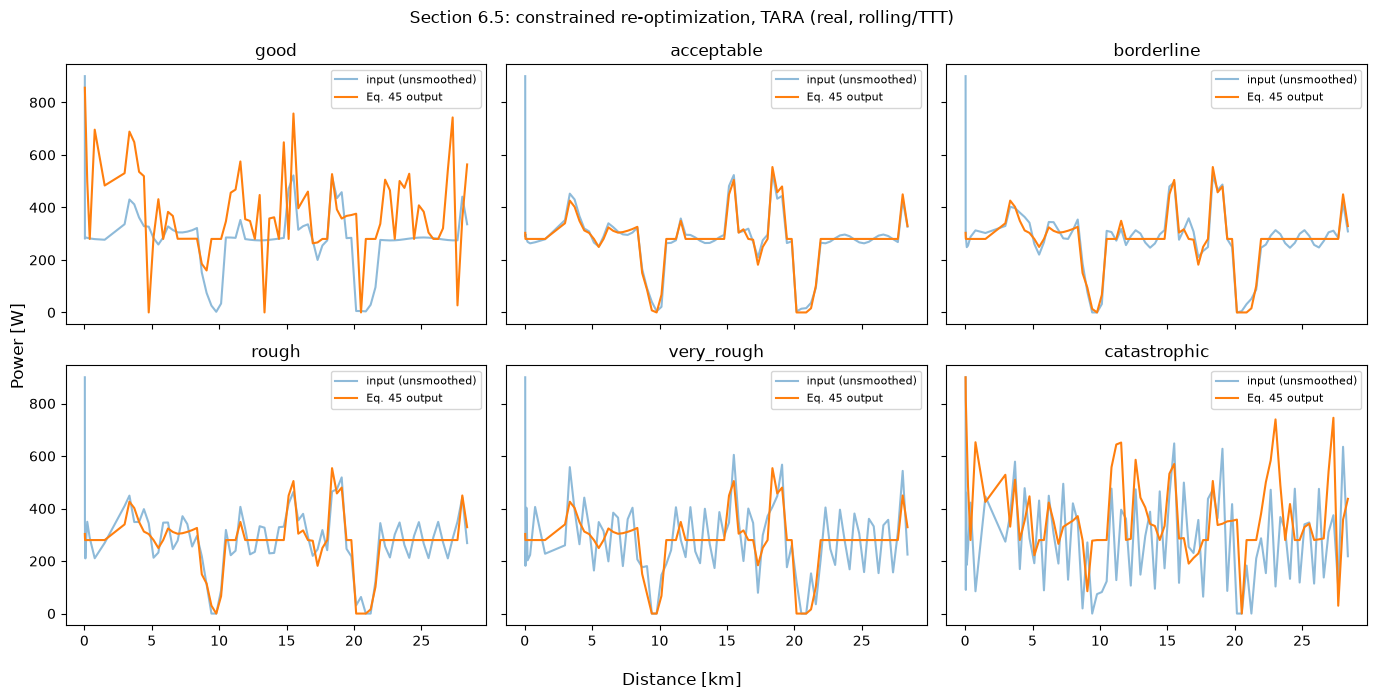

In [13]:
pc.plot_constrained_tiers(res_hs_tara, constrained_results_tara, "Section 4.5: constrained re-optimization, TARA (real, rolling/TTT)")

TARA shows the same non-converged pathology as TdF16 (4.4), but in a more
puzzling place: not the roughest tiers, but the *mildest* one.
`acceptable` through `very_rough` all return consistent plans to within
0.5 s of each other (+0.51 s vs. the 45.48 min unsmoothed baseline), yet
`good` -- the least-perturbed input of the six -- reports t_finish =
32.52 min, 777.8 s (over 17%) faster than baseline. Perturbation severity
is not what predicts failure here; this looks like SLSQP exhausting its
iteration budget on one specific warm start and returning an infeasible
point, not a property of how rough the input trace is. `catastrophic`
fails too, in the same way as TdF16's: even `"sine"` cannot bring the
realized slew under the 2.0 W/m bound here (5.71 W/m -- the row the
cross-check ledger lists as a genuine gate failure, not an oversight).
All six TARA tiers report `success=False` ("Iteration limit reached"),
including the four healthy ones. TARA is also the one course where the
SLSQP-vs-IPOPT backend cross-check diverges sharply (5.96%) and where the
baseline's own SLSQP-vs-simulator agreement (2.68%) misses its gate --
three independent checks all pointing at the same course being genuinely
harder for this solver/mesh combination than either synthetic course or
the other two real courses.

### 4.6 What `SmoothingResult.success` / `.message` do and do not tell you

Before issue #3 was fixed, `smooth_constrained` discarded the solver's
verdict, so the four bad results above (TdF16 `very_rough` and
`catastrophic`, TARA `good` and `catastrophic`) were indistinguishable
from good ones without re-checking defect residuals by hand. They now
carry `success=False` and the solver's message.

Across the 30 re-solves in this notebook, 21 report `success=False`
(flat 6/6, rolling 0/6, Giro10 3/6, TdF16 6/6, TARA 6/6). All four bad
results are among them, but so are 17 results that look perfectly
healthy (slew at the bound, time within 2.6 s of baseline). So the flag
is a necessary but not sufficient warning: `success=True` is reassuring,
`success=False` means "cross-check before trusting this" -- the same
philosophy as for `OptimizationResult.success` (agreement across backends
and the forward simulator is the real correctness argument, not the flag
alone). A physically implausible `time_total_s` (negative, or far below the
unsmoothed baseline) together with `success=False` is what every failed
re-solve here looked like.